## 5.1 양자 암호 — 깨지지 않는 보안 (Quantum Cryptography)

In [ ]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 무작위 이진 문자열을 만드는 함수
def random_bitstring(length):
    return ''.join(np.random.choice(['0', '1'], size=length))

# Alice의 키와 기저
key_length = 8
alice_key = random_bitstring(key_length)
alice_basis = random_bitstring(key_length)

# Alice의 양자 회로 생성
alice_circuits = []
for bit, basis in zip(alice_key, alice_basis):
    qc = QuantumCircuit(1, 1)
    if bit == '1':
        qc.x(0)          # 비트가 1이면 X 게이트
    if basis == '1':
        qc.h(0)          # 기저가 1(X 기저)이면 하다마드
    qc.barrier()
    alice_circuits.append(qc)

# Bob의 기저
bob_basis = random_bitstring(key_length)

# Bob의 측정 회로 생성
bob_circuits = []
for basis, qc in zip(bob_basis, alice_circuits):
    if basis == '1':
        qc.h(0)          # 기저가 1이면 측정 전에 하다마드
    qc.measure(0, 0)
    bob_circuits.append(qc)

# Qiskit Aer 시뮬레이터로 회로 실행
simulator = AerSimulator()
results = [simulator.run(transpile(qc, simulator), shots=1, memory=True).result().get_memory()[0] for qc in bob_circuits]

# Bob의 키
bob_key = ''.join(results)

# 기저를 비교해 공유 비밀키 추출 (기저가 일치한 비트만 보관)
shared_key = ''.join([bit for bit, a_basis, b_basis in zip(alice_key, alice_basis, bob_basis) if a_basis == b_basis])

print("Alice's Key: ", alice_key)
print("Alice's Basis: ", alice_basis)
print("Bob's Basis: ", bob_basis)
print("Bob's Key: ", bob_key)
print("Shared Key: ", shared_key)

Alice's Key:  01101101
Alice's Basis:  00011000
Bob's Basis:  01011111
Bob's Key:  00101101
Shared Key:  0101


이 예제에서 Alice와 Bob은 BB84 프로토콜로 공유 비밀키를 만든다. Alice는 무작위 키와 기저로 큐비트를 준비하고, Bob은 자신의 무작위 기저로 측정한다. 그다음 공개 채널로 기저를 비교해, 기저가 일치하지 않는 비트는 버리고 공유 비밀키를 남긴다.

아래는 BB84 프로토콜에 쓰인 처음 몇 개 양자 회로의 시각화다.


Circuit 1 - Alice's preparation and Bob's measurement:
Alice:


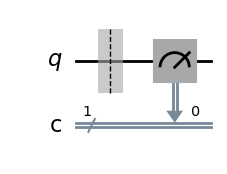

Bob:


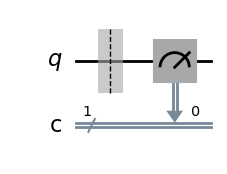


Circuit 2 - Alice's preparation and Bob's measurement:
Alice:


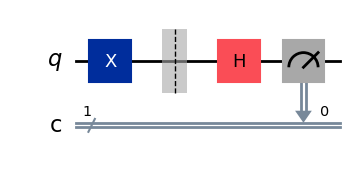

Bob:


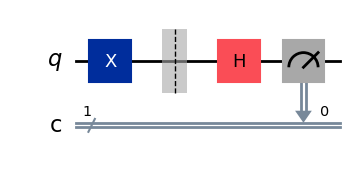


Circuit 3 - Alice's preparation and Bob's measurement:
Alice:


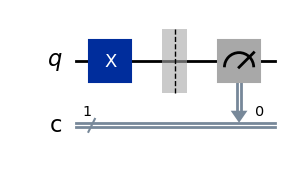

Bob:


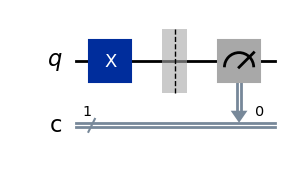

In [2]:
# 처음 몇 개 회로 시각화
for i in range(3):
    print(f"\nCircuit {i+1} - Alice's preparation and Bob's measurement:")
    print("Alice:")
    display(alice_circuits[i].draw('mpl'))
    print("Bob:")
    display(bob_circuits[i].draw('mpl'))